# S1-1 現在価値と複利規約

## 学習目標

- 割引の考え方を、単利・複利・連続複利の3系統で書き分けられる
- 年複利・半年複利・連続複利の変換式を導出し、往復で誤差ゼロを再現できる
- 割引係数（discount factor）とゼロレート（zero rate）の相互変換を、規約を指定して実行できる
- スクラッチ実装・`bondlab.rates`・QuantLib の3経路が全規約で一致することを確認できる

## 実務での位置づけ（ファンドはどう稼ぐか）

割引と複利規約は、あらゆる債券・デリバティブ評価の一番下の土台です。運用会社の
ポートフォリオ評価、ヘッジファンドの相対価値計算、銀行デスクの値付けは、すべて
「将来キャッシュフローをいくらに割り引くか」から始まります。規約を1つ取り違えると
数bpの誤差が全ポジションに波及するため、実務では最初に厳密に揃えます。


## 理論

### 割引の基本

将来の時点 $t$（単位: 年）に受け取る1単位のキャッシュフローの現在価値（present value, PV）を割引係数（discount factor）$DF(t)$ と呼びます。割引係数は「今の1単位」と「将来の1単位」を交換するレートで、$0 < DF(t) \le 1$（正の金利下）を満たします。金額 $C$ のキャッシュフローの現在価値は

$$ PV = C \cdot DF(t). $$

割引係数を金利で表す方法が複利規約（compounding convention）です。同じ $DF(t)$ でも、年に何回利息を組み入れるかで表示上のレートが変わります。

### 単利・複利・連続複利

元本1、年率 $r$ を $t$ 年運用したときの将来価値 $FV$ を規約別に書きます。

**単利（simple interest）**: 利息は元本にのみ付き、利息が利息を生みません。

$$ FV_{\text{simple}} = 1 + r t, \qquad DF(t) = \frac{1}{1 + r t}. $$

**$m$ 回複利（$m$-times compounding）**: 1年を $m$ 期に分け、各期末に利率 $r/m$ で利息を元本へ組み入れます。$t$ 年で複利は $mt$ 回働きます。

$$ FV_m = \left(1 + \frac{r}{m}\right)^{mt}, \qquad DF(t) = \left(1 + \frac{r}{m}\right)^{-mt}. $$

$m=1$ が年複利（annual）、$m=2$ が半年複利（semiannual）、$m=4$ が四半期複利（quarterly）、$m=12$ が月複利（monthly）です。

**連続複利（continuous compounding）**: $m \to \infty$ の極限です。よく知られた極限

$$ \lim_{m \to \infty} \left(1 + \frac{r}{m}\right)^{m} = e^{r} $$

を使うと、

$$ FV_{\infty} = \lim_{m \to \infty}\left(1 + \frac{r}{m}\right)^{mt} = \left(\lim_{m \to \infty}\left(1 + \frac{r}{m}\right)^{m}\right)^{t} = e^{rt}, \qquad DF(t) = e^{-rt}. $$

### 割引係数とゼロレートの関係

時点 $t$ 一括で満期を迎えるゼロクーポンから逆算した金利をゼロレート（zero rate）またはスポットレート（spot rate）と呼びます。割引係数を規約 $m$ のレートについて解くと、

$$ DF(t) = \left(1 + \frac{r}{m}\right)^{-mt}
   \;\Longleftrightarrow\;
   r = m\left(DF(t)^{-\frac{1}{mt}} - 1\right), $$

連続複利では

$$ DF(t) = e^{-rt}
   \;\Longleftrightarrow\;
   r = -\frac{\ln DF(t)}{t}. $$

割引係数はレートと年数から一意に定まり、逆にレートは割引係数と年数（と規約）から一意に定まります。この双方向の対応が、以降のカーブ・モデル層の土台です。

### 規約変換式の導出

変換の原則は「同じ $t$ で割引係数を一致させる」ことです。規約 $m$ のレート $r_m$ と規約 $n$ のレート $r_n$ が同じ $DF(t)$ を与えるなら等価とみなします。

$$ \left(1 + \frac{r_m}{m}\right)^{-mt} = \left(1 + \frac{r_n}{n}\right)^{-nt}. $$

両辺を $-1/t$ 乗すると $t$ が消えます。

$$ \left(1 + \frac{r_m}{m}\right)^{m} = \left(1 + \frac{r_n}{n}\right)^{n}
   \;\Longrightarrow\;
   r_n = n\left[\left(1 + \frac{r_m}{m}\right)^{\frac{m}{n}} - 1\right]. $$

**離散から連続**: $r_n$ の式で $n \to \infty$ を取る代わりに、$\left(1 + r_m/m\right)^{m} = e^{r_c}$ とおくのが簡明です。両辺の対数から

$$ r_c = m \ln\!\left(1 + \frac{r_m}{m}\right). $$

**連続から離散**: 上式を $r_m$ について解くと

$$ 1 + \frac{r_m}{m} = e^{r_c/m}
   \;\Longrightarrow\;
   r_m = m\left(e^{r_c/m} - 1\right). $$

いずれの変換式も $t$ を含みません。割引係数は $t$ に依存しますが、規約間のレート変換は年数によらず一定です。この事実は後で数値的に確認します。

### 年複利・半年複利・連続複利の具体変換

$m=1$（年複利）と $n=2$（半年複利）の間は上式で

$$ r_2 = 2\left[(1 + r_1)^{1/2} - 1\right], \qquad r_1 = \left(1 + \frac{r_2}{2}\right)^{2} - 1. $$

連続複利との間は

$$ r_c = \ln(1 + r_1) = 2\ln\!\left(1 + \frac{r_2}{2}\right). $$

例として年複利 $r_1 = 4\%$ は、半年複利で $r_2 = 2(\sqrt{1.04}-1) \approx 3.961\%$、連続複利で $r_c = \ln 1.04 \approx 3.922\%$ です。複利回数が増えるほど、同じ割引係数を与えるレートは小さくなります（$r_1 > r_2 > r_c$）。

### 連続複利がモデルで使われる理由

確率金利モデル（S4・S5）では、割引係数を積分で書けることが決定的に効きます。瞬間的なゼロレート（短期金利、short rate）$r(s)$ が時間変化するとき、連続複利の割引係数は

$$ DF(t) = \exp\!\left(-\int_0^{t} r(s)\, ds\right) $$

と積和ではなく指数の内側の積分で表せます。離散複利だと $\prod_k (1 + r_k/m)^{-1}$ という積になり、微分・積分の扱いが煩雑です。連続複利なら

$$ \frac{\partial}{\partial t} \ln DF(t) = -r(t) $$

のように対数微分がそのまま瞬間レートを与え、伊藤の公式や PDE 展開と噛み合います。合成も

$$ DF(0, t_2) = DF(0, t_1)\, DF(t_1, t_2) = e^{-r_1 t_1} e^{-f (t_2 - t_1)} $$

のように指数則で乗算に閉じ、フォワードレートの定義が引き算だけで済みます。

### 表示上の丸め慣行

市場慣行では、レートは年率のパーセント表示で小数第3位（0.001% = 0.1bp）程度まで、割引係数は小数第6〜8位まで持つのが一般的です。1ベーシスポイント（basis point, bp）は 0.01% = $10^{-4}$ です。計算は倍精度浮動小数点で丸めず行い、表示の直前でのみ丸めます。途中で丸めるとゼロレートの逆算やカーブ剥ぎ取りで誤差が累積するためです。

## スクラッチ実装

理論の変換式をそのままコードに落とします。まず自作関数の仕様を示し、次に
`bondlab.rates` と同じ結果になることを確認します。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `freq(convention)` | 複利規約（str） | 年間複利回数 int または None | 規約名を複利回数 $m$ へ写す（連続は None） |
| `df_scratch(rate, t, convention)` | レート, 年数, 規約 | 割引係数 | $DF=(1+r/m)^{-mt}$ または $e^{-rt}$ |
| `rate_scratch(df, t, convention)` | 割引係数, 年数, 規約 | レート | 割引係数からレートを逆算（`df_scratch` の逆関数） |
| `to_cont_scratch(rate, convention)` | レート, 規約 | 連続複利レート | $r_c=m\ln(1+r/m)$（$t$ 非依存） |
| `from_cont_scratch(rate_c, convention)` | 連続複利レート, 規約 | 離散レート | $r_m=m(e^{r_c/m}-1)$（$t$ 非依存） |

In [1]:
import numpy as np

np.random.seed(0)

# 規約名 -> 年間複利回数。連続複利は None。
_FREQ = {
    "annual": 1,
    "semiannual": 2,
    "quarterly": 4,
    "monthly": 12,
    "continuous": None,
}


def freq(convention):
    """複利規約名を年間複利回数 m へ変換する。連続複利は None を返す。"""
    if convention not in _FREQ:
        raise ValueError(f"未知の複利規約: {convention!r}")
    return _FREQ[convention]


def df_scratch(rate, t, convention):
    """レート r と年数 t から割引係数を計算する。"""
    m = freq(convention)
    r = np.asarray(rate, dtype=float)
    tt = np.asarray(t, dtype=float)
    if m is None:  # 連続複利: DF = exp(-r t)
        return np.exp(-r * tt)
    return (1.0 + r / m) ** (-m * tt)  # m 回複利: DF = (1 + r/m)^(-m t)


def rate_scratch(df, t, convention):
    """割引係数からレートを逆算する（df_scratch の逆関数）。"""
    m = freq(convention)
    d = np.asarray(df, dtype=float)
    tt = np.asarray(t, dtype=float)
    if m is None:  # r = -ln(DF)/t
        return -np.log(d) / tt
    return m * (d ** (-1.0 / (m * tt)) - 1.0)  # r = m(DF^(-1/(mt)) - 1)


def to_cont_scratch(rate, convention):
    """m 回複利レートを連続複利レートへ変換する（t 非依存）。"""
    m = freq(convention)
    r = np.asarray(rate, dtype=float)
    if m is None:
        return r
    return m * np.log1p(r / m)  # r_c = m ln(1 + r/m)


def from_cont_scratch(rate_c, convention):
    """連続複利レートを m 回複利レートへ変換する（t 非依存）。"""
    m = freq(convention)
    rc = np.asarray(rate_c, dtype=float)
    if m is None:
        return rc
    return m * (np.exp(rc / m) - 1.0)  # r_m = m(exp(r_c/m) - 1)

導出した具体値を数値で確認します。年複利 4% を半年複利・連続複利へ変換します。

In [2]:
r1 = 0.04
print(f"年複利           r1 = {r1:.6%}")
print(f"半年複利  r2 = {from_cont_scratch(to_cont_scratch(r1, 'annual'), 'semiannual'):.6%}")
print(f"連続複利  rc = {to_cont_scratch(r1, 'annual'):.6%}")

# 手計算の閉じた式と一致するか。
print("sqrt 式との一致:", np.isclose(
    from_cont_scratch(to_cont_scratch(r1, "annual"), "semiannual"),
    2 * (np.sqrt(1 + r1) - 1),
))
print("ln 式との一致  :", np.isclose(to_cont_scratch(r1, "annual"), np.log1p(r1)))

年複利           r1 = 4.000000%
半年複利  r2 = 3.960781%
連続複利  rc = 3.922071%
sqrt 式との一致: True
ln 式との一致  : True


スクラッチ実装が `bondlab.rates` と全規約・広い範囲で一致することを確認します。
レート $[-1\%, 20\%]$、年数 $[0.25, 40]$ 年の格子で最大絶対誤差を測ります。

In [3]:
from bondlab import rates

conventions = ["annual", "semiannual", "quarterly", "monthly", "continuous"]
grid_r = np.linspace(-0.01, 0.20, 22)
grid_t = np.array([0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 40.0])
R, T = np.meshgrid(grid_r, grid_t)

print(f"{'規約':12s} {'DF 最大誤差':>14s} {'rate 最大誤差':>16s} {'to_cont 最大誤差':>18s}")
for conv in conventions:
    df_s = df_scratch(R, T, conv)
    df_b = rates.discount_factor(R, T, conv)
    rate_s = rate_scratch(df_b, T, conv)
    rate_b = rates.rate_from_discount(df_b, T, conv)
    cont_s = to_cont_scratch(grid_r, conv)
    cont_b = rates.to_continuous(grid_r, conv)
    e_df = np.max(np.abs(df_s - df_b))
    e_rate = np.max(np.abs(rate_s - rate_b))
    e_cont = np.max(np.abs(cont_s - cont_b))
    print(f"{conv:12s} {e_df:14.2e} {e_rate:16.2e} {e_cont:18.2e}")
    assert e_df < 1e-12 and e_rate < 1e-12 and e_cont < 1e-12

print("スクラッチ実装は bondlab.rates と全規約で一致しました")

規約                  DF 最大誤差        rate 最大誤差       to_cont 最大誤差
annual             0.00e+00         0.00e+00           0.00e+00
semiannual         0.00e+00         0.00e+00           0.00e+00
quarterly          0.00e+00         0.00e+00           0.00e+00
monthly            0.00e+00         0.00e+00           0.00e+00
continuous         0.00e+00         0.00e+00           0.00e+00
スクラッチ実装は bondlab.rates と全規約で一致しました


## QuantLib検証

QuantLib の `InterestRate` クラスは、複利規約・頻度・デイカウントを保持し、
割引係数と等価レートを計算します。スクラッチ／`bondlab` と全規約で突き合わせます。

QuantLib の頻度への対応は次の通りです。`Actual365Fixed` を使いますが、以下では
年数 $t$ を直接渡すため、デイカウントは結果に影響しません（`discountFactor(t)` は
時間 $t$ を年単位でそのまま解釈します）。

In [4]:
import QuantLib as ql

ql_freq = {
    "annual": (ql.Compounded, ql.Annual),
    "semiannual": (ql.Compounded, ql.Semiannual),
    "quarterly": (ql.Compounded, ql.Quarterly),
    "monthly": (ql.Compounded, ql.Monthly),
    "continuous": (ql.Continuous, ql.NoFrequency),
}
dc = ql.Actual365Fixed()

r_test = 0.05
t_test = 3.0
print(f"入力: r = {r_test:.2%}, t = {t_test} 年\n")
print(f"{'規約':12s} {'QuantLib DF':>16s} {'bondlab DF':>16s} {'scratch DF':>16s}")
for conv in conventions:
    comp, fq = ql_freq[conv]
    ir = ql.InterestRate(r_test, dc, comp, fq)
    df_q = ir.discountFactor(t_test)
    df_b = float(rates.discount_factor(r_test, t_test, conv))
    df_s = float(df_scratch(r_test, t_test, conv))
    print(f"{conv:12s} {df_q:16.10f} {df_b:16.10f} {df_s:16.10f}")
    assert abs(df_q - df_b) < 1e-10
    assert abs(df_q - df_s) < 1e-10

入力: r = 5.00%, t = 3.0 年

規約                QuantLib DF       bondlab DF       scratch DF
annual           0.8638375985     0.8638375985     0.8638375985
semiannual       0.8622968660     0.8622968660     0.8622968660
quarterly        0.8615086004     0.8615086004     0.8615086004
monthly          0.8609762447     0.8609762447     0.8609762447
continuous       0.8607079764     0.8607079764     0.8607079764


次に、各規約 5% を連続複利へ変換した等価レートを、QuantLib の
`equivalentRate` とスクラッチで突き合わせます。

In [5]:
print(f"{'規約':12s} {'QL→連続 (%)':>14s} {'scratch→連続 (%)':>18s} {'差 (bp)':>12s}")
for conv in conventions:
    comp, fq = ql_freq[conv]
    ir = ql.InterestRate(r_test, dc, comp, fq)
    # equivalentRate(compounding, freq, t) は同じ DF を保つ等価レートを返す。
    eq_q = ir.equivalentRate(ql.Continuous, ql.NoFrequency, t_test).rate()
    eq_s = float(to_cont_scratch(r_test, conv))
    diff_bp = (eq_q - eq_s) * 1e4
    print(f"{conv:12s} {eq_q*100:14.8f} {eq_s*100:18.8f} {diff_bp:12.2e}")
    assert abs(eq_q - eq_s) < 1e-10

print("QuantLib・bondlab・スクラッチの3経路が全規約で一致しました")

規約                QL→連続 (%)     scratch→連続 (%)       差 (bp)
annual           4.87901642         4.87901642     3.47e-13
semiannual       4.93852252         4.93852252    -1.87e-12
quarterly        4.96900800         4.96900800    -1.73e-12
monthly          4.98961218         4.98961218    -1.46e-12
continuous       5.00000000         5.00000000    -2.08e-13
QuantLib・bondlab・スクラッチの3経路が全規約で一致しました


## 実データ適用

合成のゼロレート（連続複利）をいくつか置き、割引係数カーブを作ります。実データ
は使わず、教科書的な右肩上がりのカーブを手で与えます。作った割引係数を各規約の
ゼロレートへ逆算し、表示上どれだけ差が出るかを見ます。

In [6]:
import pandas as pd

# 満期（年）と連続複利ゼロレート。順イールドの合成カーブ。
tenors = np.array([0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0])
zero_cont = np.array([0.010, 0.013, 0.017, 0.020, 0.024, 0.026, 0.028, 0.031, 0.032])

# 連続複利ゼロレートから割引係数カーブを作る。
df_curve = rates.discount_factor(zero_cont, tenors, "continuous")

# 同じ割引係数を各規約のゼロレートへ逆算する。
table = {"満期(年)": tenors, "DF": df_curve}
for conv in conventions:
    table[conv] = rates.rate_from_discount(df_curve, tenors, conv) * 100  # %表示

curve = pd.DataFrame(table)
curve_disp = curve.copy()
curve_disp["DF"] = curve_disp["DF"].map(lambda x: f"{x:.6f}")
for conv in conventions:
    curve_disp[conv] = curve_disp[conv].map(lambda x: f"{x:.4f}")
print("割引係数カーブと規約別ゼロレート（%）")
print(curve_disp.to_string(index=False))

割引係数カーブと規約別ゼロレート（%）
 満期(年)       DF annual semiannual quarterly monthly continuous
   0.5 0.995012 1.0050     1.0025    1.0013  1.0004     1.0000
   1.0 0.987084 1.3085     1.3042    1.3021  1.3007     1.3000
   2.0 0.966572 1.7145     1.7072    1.7036  1.7012     1.7000
   3.0 0.941765 2.0201     2.0100    2.0050  2.0017     2.0000
   5.0 0.886920 2.4290     2.4145    2.4072  2.4024     2.4000
   7.0 0.833601 2.6341     2.6170    2.6085  2.6028     2.6000
  10.0 0.755784 2.8396     2.8197    2.8098  2.8033     2.8000
  20.0 0.537944 3.1486     3.1241    3.1120  3.1040     3.1000
  30.0 0.382893 3.2518     3.2257    3.2128  3.2043     3.2000


割引係数はどの規約でも同一で、表示レートだけが規約により変わります。複利回数が
多い規約ほどレートは小さく（continuous < monthly < quarterly < semiannual <
annual）、その差は満期にほぼ依存しません。数値でその大小関係を確認します。

In [7]:
# 各満期で annual >= semiannual >= quarterly >= monthly >= continuous を確認。
ordered = curve[["annual", "semiannual", "quarterly", "monthly", "continuous"]].to_numpy()
assert np.all(np.diff(ordered, axis=1) <= 1e-9), "規約の大小関係が崩れています"
print("大小関係 annual >= semiannual >= quarterly >= monthly >= continuous を全満期で確認")

# annual と continuous の差（bp）は満期でほぼ一定。
gap_bp = (curve["annual"] - curve["continuous"]) * 100
print("annual − continuous の差 (bp):", np.round(gap_bp.to_numpy(), 3))

大小関係 annual >= semiannual >= quarterly >= monthly >= continuous を全満期で確認
annual − continuous の差 (bp): [0.502 0.849 1.453 2.013 2.903 3.409 3.957 4.855 5.175]


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


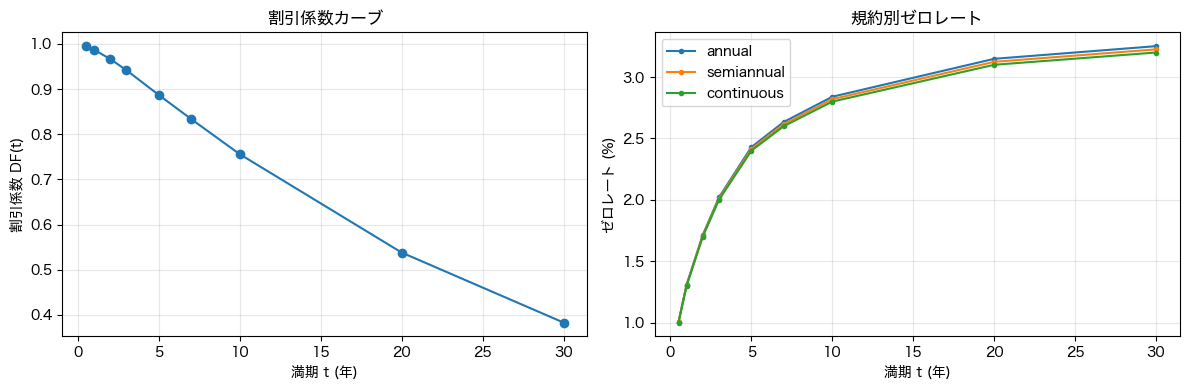

In [8]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(tenors, df_curve, marker="o")
ax1.set_xlabel("満期 t (年)")
ax1.set_ylabel("割引係数 DF(t)")
ax1.set_title("割引係数カーブ")
ax1.grid(alpha=0.3)

for conv in ["annual", "semiannual", "continuous"]:
    ax2.plot(tenors, curve[conv], marker=".", label=conv)
ax2.set_xlabel("満期 t (年)")
ax2.set_ylabel("ゼロレート (%)")
ax2.set_title("規約別ゼロレート")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 演習

1. **往復誤差ゼロのテスト**: 半年複利 5% を連続複利・月複利へ変換し、さらに
   半年複利へ戻したとき、元の 5% との絶対誤差が $10^{-12}$ 未満であることを
   `assert` で確認せよ。スクラッチ関数と `bondlab.rates` の両方で行い、両者の
   結果が一致することも確認せよ。
2. **同一 DF からの逆算**: 年数 $t=4$、割引係数 $DF=0.85$ を固定し、5規約すべての
   ゼロレートを逆算せよ。逆算したレートから割引係数を再計算すると、すべて
   0.85 に戻ることを確認せよ。さらに、逆算レートが
   annual >= semiannual >= quarterly >= monthly >= continuous の順に並ぶことを
   確認せよ。

解答例は `solutions/S1/sol_0101.py`。

## 用語集

定義の正は `glossary/01_bond_basics.md`。ここでは初出語の一行要約のみ示します。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| 割引係数 | discount factor | 将来1単位の現在価値。$m$回複利で $(1+r/m)^{-mt}$、連続複利で $e^{-rt}$ |
| 連続複利 | continuous compounding | 複利回数を無限大にした極限。$DF=e^{-rt}$、$r_c=m\ln(1+r/m)$ |
| スポットレート | spot rate | 時点 $t$ 満期のゼロクーポンから逆算した金利。ゼロレートに同じ |
| 現在価値 | present value | 将来キャッシュフローを割引係数で今に引き直した価値 $PV=C\cdot DF(t)$ |